In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/..")
from analysis import Analysis

Setting weight for mc to 1.00e+00


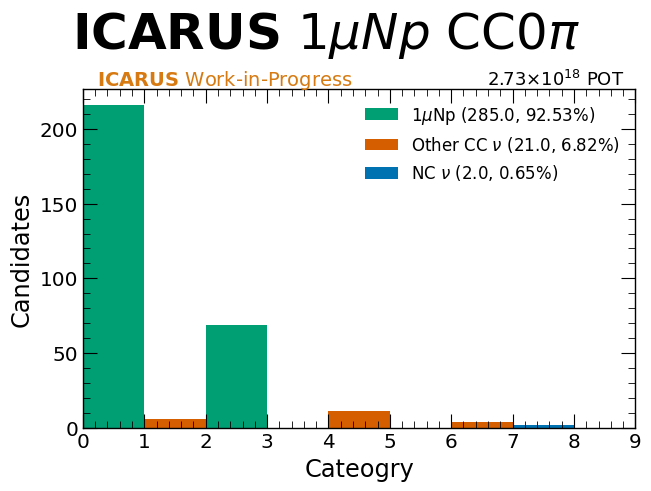

In [ ]:
cfg = """
[[this_includes]]
file = '../configurations/common/variables.toml'

[[this_includes]]
file = '../configurations/common/styles.toml'

[samples]
[samples.mc]
key = "nominal"
exposure_type = "pot"
trees = ['selected']

[output]
path = '/exp/icarus/app/users/kyjung/medulla_work'

[analysis]
ordinate_sample = 'mc'
category_branch = 'true_category'
category_assignment = [[0,2], [1,3,4,5,6], [7], [-1,8]]
category_labels = ['1$\\mu$Np', 'Other CC $\\nu$', 'NC $\\nu$', 'Cosmic']
category_colors = ['C0', 'C1', 'C3', 'C4', 'black']
category_types = ['histogram', 'histogram', 'histogram', 'histogram']

[[figure]]
name = 'true_category'
type = 'SimpleFigure'
style = 'selected_icarus'
[[figure.artists]]
type = 'SpineSpectra1D'
variable = 'true_category'
draw_kwargs = {'show_component_number' = true, 'show_component_percentage' = true, 'invert_stack_order' = false}
"""
# Write the string to a file
with open('cfg.toml', 'w') as f:
    f.write(cfg)

file = '/exp/icarus/app/users/kyjung/medulla_work/medulla/build/icarus_disappearance.root'

analysis = Analysis('cfg.toml', file)
analysis.run(close_figs=False)

   { name = "neutrino",              type = "true" },
    { name = "fiducial_cut",          type = "true" },
    { name = "containment_cut",       type = "true" },
    { name = "no_photons",            type = "true",  parameters = [25.0] },
    { name = "no_electrons",          type = "true",  parameters = [25.0] },
    { name = "no_charged_pions",      type = "true",  parameters = [25.0] },
    { name = "single_muon",           type = "true",  parameters = [143.425] },
    { name = "!no_protons",           type = "true",  parameters = [50.0] },
    { name = "trigger_emulation_cut", type = "event", decrements_exposure = false },

Setting weight for signal to 1.00e+00
[SpineEfficiency.draw] Results columns before subsetting: ['   ', 'Cut', 'Efficiency [%]', 'Cumulative [%]', 'Differential\nEfficiency [%]', 'Cumulative\nEfficiency [%]']
[SpineEfficiency.draw] Columns to select: ['Cut', 'Differential\nEfficiency [%]', 'Cumulative\nEfficiency [%]']
[SpineEfficiency.draw] Results columns after renaming: ['Cut', 'Differential\nEfficiency [%]', 'Cumulative\nEfficiency [%]']


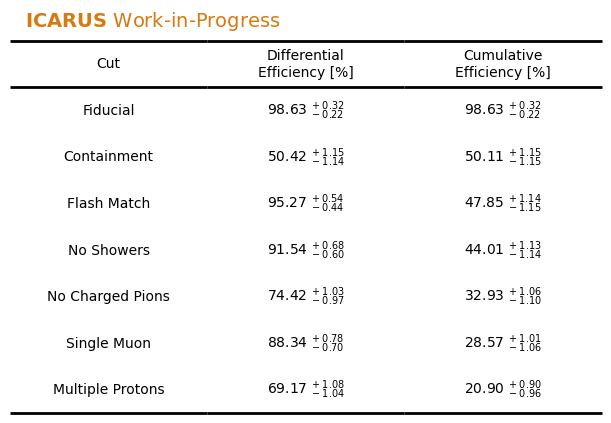

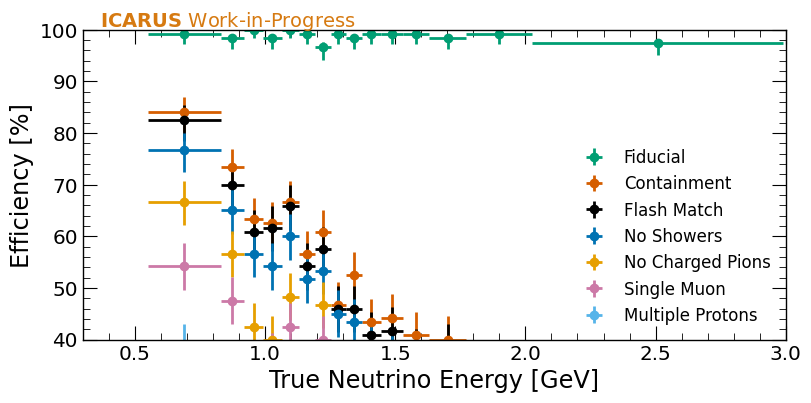

In [ ]:
cfg = r"""
[samples.signal]
key = "nominal"
exposure_type = "pot"
trees = ['signal',]
precompute = {'reco_flash_cut' = 'reco_flash_time > -0.5 and reco_flash_time < 1.6', 'has_no_showers' = 'reco_photon_multiplicity == 0 and reco_electron_multiplicity == 0', 'has_no_charged_pions' = 'reco_pion_multiplicity == 0', 'has_single_muon' = 'reco_muon_multiplicity == 1', 'has_multiple_protons' = 'reco_proton_multiplicity > 0', 'all_cuts' = 'reco_flash_time > -0.5 and reco_flash_time < 1.6 and reco_photon_multiplicity == 0 and reco_electron_multiplicity == 0 and reco_pion_multiplicity == 0 and reco_muon_multiplicity == 1 and reco_proton_multiplicity > 0 and reco_fiducial_cut == 1 and reco_containment_cut == 1'}

[[style]]
name = 'basic_icarus'
style_sheet = "/exp/icarus/app/users/kyjung/medulla_work/medulla/spineplot/styles/muon2024.mplstyle"
markers = ['o', '^', 's', 'P', 'D']
default_figsize = [6.4,4.8]
title = ''
mark_pot = false
mark_preliminary = '$\bf{ICARUS}$ Work-in-Progress'
plot_kwargs = {'histtype' = 'barstacked', 'stacked' = true}

[variables.true_neutrino_energy_eqpop]
key = "true_neutrino_energy"
range = [0.3, 3.0]
nbins = 15
binning_scheme = "equal_population"
xlabel = "True Neutrino Energy [GeV]"

[output]
path = '/exp/icarus/app/users/kyjung/medulla_work'

[analysis]
ordinate_sample = 'signal'
category_branch = 'category'
category_assignment = [[0,2], [1,3,4,5,6], [7], [-1,8]]
category_labels = ['1$\mu$Np', 'Other CC $\nu$', 'NC $\nu$', 'Cosmic']
category_colors = ['C0', 'C1', 'C3', 'C4']
category_types = ['histogram', 'histogram', 'histogram', 'histogram']

[[figure]]
name = 'efficiency_table'
type = 'SimpleFigure'
style = 'basic_icarus'
figsize = [6.0, 4.2]

[[figure.artists]]
type = 'SpineEfficiency'
variable = 'true_neutrino_energy_eqpop'
groups = ['1$\mu$Np',]
cuts = {'reco_fiducial_cut' = 'Fiducial', 'reco_containment_cut' = 'Containment', 'reco_flash_cut' = 'Flash Match', 'has_no_showers' = 'No Showers', 'has_no_charged_pions' = 'No Charged Pions', 'has_single_muon' = 'Single Muon', 'has_multiple_protons' = 'Multiple Protons'}
draw_kwargs = {'show_option' = 'table', percentage = true, 'show_seqeff' = true, 'show_unseqeff' = true, npts=1e5}

[[figure]]
name = 'efficiency_true_neutrino_energy'
type = 'SimpleFigure'
style = 'basic_icarus'
figsize = [8.0, 4.0]
[[figure.artists]]
type = 'SpineEfficiency'
variable = 'true_neutrino_energy_eqpop'
groups = ['1$\mu$Np',]
cuts = {'reco_fiducial_cut' = 'Fiducial', 'reco_containment_cut' = 'Containment', 'reco_flash_cut' = 'Flash Match', 'has_no_showers' = 'No Showers', 'has_no_charged_pions' = 'No Charged Pions', 'has_single_muon' = 'Single Muon', 'has_multiple_protons' = 'Multiple Protons'}
draw_kwargs = {'show_option' = 'differential', percentage = true, 'show_seqeff' = true, 'show_unseqeff' = true, npts=1e5, yrange = [40, 100]}
"""

# Write the string to a file
with open('cfg.toml', 'w') as f:
    f.write(cfg)

file = '/exp/icarus/app/users/kyjung/medulla_work/medulla/build/icarus_disappearance.root'

analysis = Analysis('cfg.toml', file)
analysis.run(close_figs=False)

Setting weight for signal to 1.00e+00


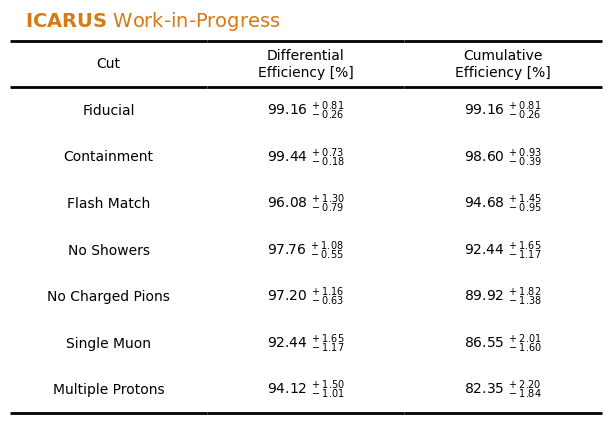

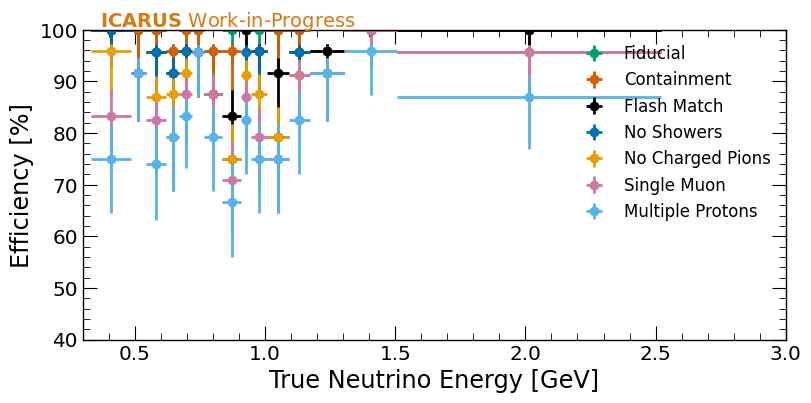

In [5]:
cfg = r"""
[samples.signal]
key = "nominal"
exposure_type = "pot"
trees = ['signal',]
precompute = {'reco_flash_cut' = 'reco_flash_time > -0.5 and reco_flash_time < 1.6', 'has_no_showers' = 'reco_photon_multiplicity == 0 and reco_electron_multiplicity == 0', 'has_no_charged_pions' = 'reco_pion_multiplicity == 0', 'has_single_muon' = 'reco_muon_multiplicity == 1', 'has_multiple_protons' = 'reco_proton_multiplicity > 0', 'all_cuts' = 'reco_flash_time > -0.5 and reco_flash_time < 1.6 and reco_photon_multiplicity == 0 and reco_electron_multiplicity == 0 and reco_pion_multiplicity == 0 and reco_muon_multiplicity == 1 and reco_proton_multiplicity > 0 and reco_fiducial_cut == 1 and reco_containment_cut == 1'}

[[style]]
name = 'basic_icarus'
style_sheet = "/exp/icarus/app/users/kyjung/medulla_work/medulla/spineplot/styles/muon2024.mplstyle"
markers = ['o', '^', 's', 'P', 'D']
default_figsize = [6.4,4.8]
title = ''
mark_pot = false
mark_preliminary = '$\bf{ICARUS}$ Work-in-Progress'
plot_kwargs = {'histtype' = 'barstacked', 'stacked' = true}

[variables.true_neutrino_energy_eqpop]
key = "true_neutrino_energy"
range = [0.3, 3.0]
nbins = 15
binning_scheme = "equal_population"
xlabel = "True Neutrino Energy [GeV]"

[output]
path = '/exp/icarus/app/users/kyjung/medulla_work'

[analysis]
ordinate_sample = 'signal'
category_branch = 'category'
category_assignment = [[0,2], [1,3,4,5,6], [7], [-1,8]]
category_labels = ['1$\mu$Np', 'Other CC $\nu$', 'NC $\nu$', 'Cosmic']
category_colors = ['C0', 'C1', 'C3', 'C4']
category_types = ['histogram', 'histogram', 'histogram', 'histogram']

[[figure]]
name = 'efficiency_table'
type = 'SimpleFigure'
style = 'basic_icarus'
figsize = [6.0, 4.2]

[[figure.artists]]
type = 'SpineEfficiency'
variable = 'true_neutrino_energy_eqpop'
groups = ['1$\mu$Np',]
cuts = {'reco_fiducial_cut' = 'Fiducial', 'reco_containment_cut' = 'Containment', 'reco_flash_cut' = 'Flash Match', 'has_no_showers' = 'No Showers', 'has_no_charged_pions' = 'No Charged Pions', 'has_single_muon' = 'Single Muon', 'has_multiple_protons' = 'Multiple Protons'}
draw_kwargs = {'show_option' = 'table', percentage = true, 'show_seqeff' = true, 'show_unseqeff' = true, npts=1e5}

[[figure]]
name = 'efficiency_true_neutrino_energy'
type = 'SimpleFigure'
style = 'basic_icarus'
figsize = [8.0, 4.0]
[[figure.artists]]
type = 'SpineEfficiency'
variable = 'true_neutrino_energy_eqpop'
groups = ['1$\mu$Np',]
cuts = {'reco_fiducial_cut' = 'Fiducial', 'reco_containment_cut' = 'Containment', 'reco_flash_cut' = 'Flash Match', 'has_no_showers' = 'No Showers', 'has_no_charged_pions' = 'No Charged Pions', 'has_single_muon' = 'Single Muon', 'has_multiple_protons' = 'Multiple Protons'}
draw_kwargs = {'show_option' = 'differential', percentage = true, 'show_seqeff' = true, 'show_unseqeff' = true, npts=1e5, yrange = [40, 100]}
"""

# Write the string to a file
with open('cfg.toml', 'w') as f:
    f.write(cfg)

file = '/exp/icarus/app/users/kyjung/medulla_work/medulla/build/icarus_disappearance.root'

analysis = Analysis('cfg.toml', file)
analysis.run(close_figs=False)